# Handwritten Digit Classification using CNN and RNN

## 1. Import Libraries

In [6]:
import torch
import torch.nn as nn

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import torch.optim as optim

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = MNIST(root="../data", train=True, download=True, transform=transform)
testset = MNIST(root="../data", train=False, download=True, transform=transform)

## 3. Create Training and Validation Sets

The original MNIST training dataset contains 60,000 images.  
We split it into training and validation sets so that the validation set can be used to monitor model performance during development.

The test set is kept separate and will be used only for the final evaluation of the CNN and RNN models.

In [8]:
train_size = int(.9 * len(trainset))
val_size = len(trainset) - train_size

train_data, val_data = random_split(
    trainset,
    [train_size, val_size]
)

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(testset))

Training samples: 54000
Validation samples: 6000
Test samples: 10000


## 4. Create DataLoaders

In [9]:
trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
valloader = DataLoader(val_data, batch_size=32, shuffle=False)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

In [10]:
train_images, train_labels = next(iter(trainloader))
val_images, val_labels = next(iter(valloader))
test_images, test_labels = next(iter(testloader))

print("Training batch shape:", train_images.shape)
print("Validation batch shape:", val_images.shape)
print("Test batch shape:", test_images.shape)

Training batch shape: torch.Size([32, 1, 28, 28])
Validation batch shape: torch.Size([32, 1, 28, 28])
Test batch shape: torch.Size([32, 1, 28, 28])


## 5. Explore the Dataset

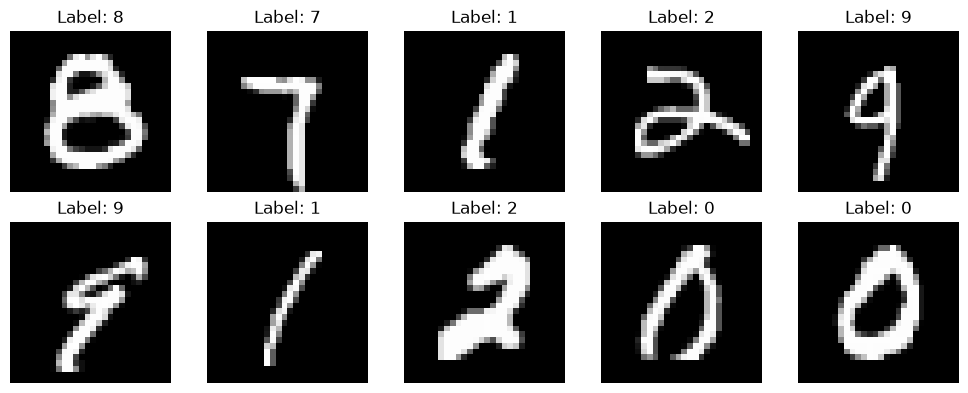

In [11]:
import matplotlib.pyplot as plt

images, labels = next(iter(trainloader))

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
print("Image shape:", images[0].shape)
print("Label:", labels[0].item())
print("Minimum pixel value:", images[0].min().item())
print("Maximum pixel value:", images[0].max().item())

Image shape: torch.Size([1, 28, 28])
Label: 8
Minimum pixel value: -1.0
Maximum pixel value: 1.0



## 6. Build CNN Model


In [13]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layer = nn.Sequential(
            #input 1 x 28 x 28
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 32 x 14 x 14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 64 x 7 x 7
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
            # 128 x 3 x 3
        )

        self.fc_layer = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 3 * 3 , 128),
            nn.ReLU(),

            nn.Linear(128,10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)

        return x



In [14]:
device = torch.device("cuda" if(torch.cuda.is_available()) else "cpu")
model = CNN()
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## 7. Train CNN

In [22]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_train_loss = 0

    for images, labels in trainloader:
        optimizer.zero_grad()
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss/len(trainloader)

    #Validation
    model.eval()
    running_val_loss = 0
    best_val_loss = float("inf")

    with torch.no_grad():
        correct_labels = 0
        total_labels = 0
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss/len(valloader)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "../models/best_cnn_model.pth")

    print(f"epoch: {epoch+1}/{epochs} => training loss = {epoch_train_loss:.4f}, validation loss = {epoch_val_loss:.4f}")



epoch: 1/10 => training loss = 0.0097, validation loss = 0.0468
epoch: 2/10 => training loss = 0.0071, validation loss = 0.0600
epoch: 3/10 => training loss = 0.0078, validation loss = 0.0608
epoch: 4/10 => training loss = 0.0079, validation loss = 0.0446
epoch: 5/10 => training loss = 0.0083, validation loss = 0.0571
epoch: 6/10 => training loss = 0.0057, validation loss = 0.0480
epoch: 7/10 => training loss = 0.0056, validation loss = 0.0513
epoch: 8/10 => training loss = 0.0050, validation loss = 0.0593
epoch: 9/10 => training loss = 0.0071, validation loss = 0.0521
epoch: 10/10 => training loss = 0.0059, validation loss = 0.0592


## 8. Load the Best CNN Model

In [15]:
model = CNN()

model.load_state_dict(
    torch.load(
        "../models/best_cnn_model.pth",
        map_location= torch.device(device)
    )
)

print("Best CNN model loaded successfully.")


Best CNN model loaded successfully.


## 9. Evaluate CNN

In [16]:
correct_labels = 0
total_labels = 0

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)       #shape [32, 10]
        _,predicted= torch.max(outputs, 1)     # 1 => col

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

test_accuracy = correct_labels / total_labels * 100
print(f"Model Accurracy = {test_accuracy:.4f}")

Model Accurracy = 99.1500


### CNN Test Accuracy

The best CNN model achieved a test accuracy of **99.15%** on the MNIST test dataset.

## 10. CNN Confusion Matrix

In [17]:
all_labels = []
all_predictions = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _,predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_predictions)
print(cm)

[[ 979    0    0    0    0    0    0    1    0    0]
 [   1 1132    1    0    0    0    0    1    0    0]
 [   1    1 1026    0    0    0    0    3    1    0]
 [   0    0    2 1001    0    3    0    3    1    0]
 [   0    1    1    0  975    0    1    0    0    4]
 [   1    0    0    8    0  879    1    2    0    1]
 [   3    1    2    0    0    0  950    0    2    0]
 [   1    4    6    0    1    0    0 1014    0    2]
 [   2    0    2    2    1    0    0    0  965    2]
 [   1    0    0    0    6    1    0    4    3  994]]


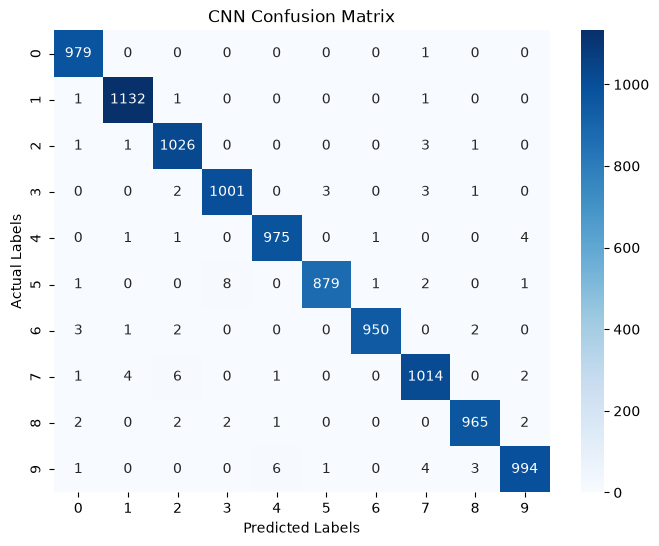

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("CNN Confusion Matrix")

plt.show()